# This script provides a template for reading in, preprocessing, EDA, and logistic regression for the news case study.

## Import Necessary Libraries

In [2]:
# Feel free to add additional libraries if needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

## Read in dataset (make sure you have the .csv files downloaded to the same directory as this notebook)

In [4]:
# Read in data
real = pd.read_csv('True.csv')

fake = pd.read_csv('Fake.csv')

## Suggested preprocessing:

### 1. Check for/remove any NaN values
### 2. Add a column labeling each headline as real or fake
### 3. Combine real and fake dataframes
### 4. Remove any missing or empty headlines

In [ ]:
# Preprocessing code goes here (add cells as needed):

## Suggested EDA:

### 1. Visualize distribution of subjects in real versus fake headlines
### 2. Visualize headline length in real versus fake headlines

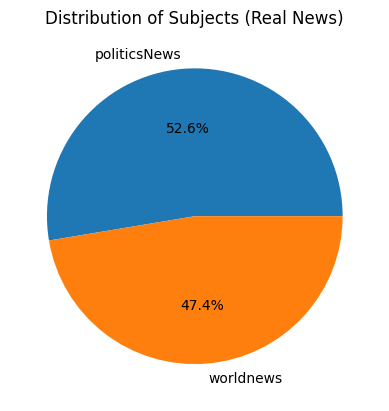

In [5]:
# Example subject distribution visualization code/output:
real_subject_frequencies = real['subject'].value_counts() # count unique subjects

# Plot value counts directly as a pie chart
real_subject_frequencies.plot(kind='pie', autopct='%1.1f%%', title='Distribution of Subjects (Real News)')
plt.ylabel('')

plt.savefig('Distribution_of_Subjects_Real.png',
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.25
           )
plt.show()

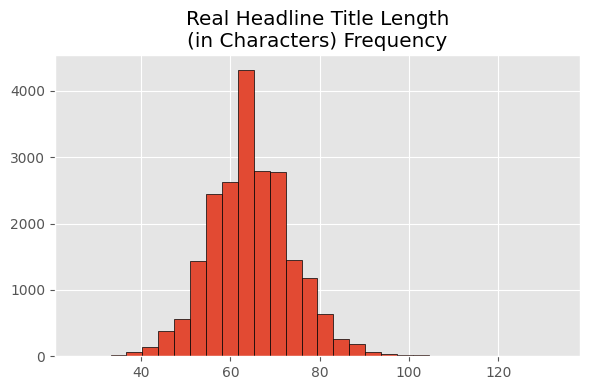

In [7]:
# Example headline length distribution visualization code/output:
plt.style.use('ggplot')

# Find the length of each string in each cell for the real news dataset
real_len = real.apply(lambda col: col.str.len())
real_titles = real_len['title'].dropna()

fig_real, ax_real = plt.subplots(figsize=(6, 4))

ax_real.hist(real_titles, bins=30, edgecolor='black')
ax_real.set_title('Real Headline Title Length\n(in Characters) Frequency')

fig_real.tight_layout()

fig_real.savefig(
    'Real_Headline_Length_Distribution.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.25
)

plt.show()

In [ ]:
# EDA code goes here (add cells as needed):

## Logistic Regression Pipeline

### 1. Split into training and testing sets

In [ ]:
# Define title as input variable and label (real vs. fake) as the predicted variable

# "clean" should be a dataframe generated via preprocessing containing both real and fake headlines with the title and label as columns
X = clean["title"] 
y = clean["label"]

# Split data (80% training, 20% testing recommended)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=36, # feel free to change this; this just ensures a consistent outcome each time you re-run script
    stratify=y
)

### 2. Create model pipeline including TF-IDF and logistic regression

#### Visit the following link for TF-IDF documentation: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

#### Visit the following link for logistic regression documentation: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [ ]:
# Create TF-IDF + Logistic Regression model pipeline: "Pipeline" allows you to sequentially transform data
# In this case, we first want to transform using TF-IDF, then using logistic regression (lr)

# This is where you should play with tuning different parameters (see links above)
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")), # removes words that convey little meaning such as "it," "the," "is," etc.
    ("lr", LogisticRegression(max_iter=1000))
])

# Train the model
model.fit(X_train, y_train)

In [ ]:
# Feel free to generate different models with different parameters in additional cells

### 3. Generate predictions using your model and evaluate performance

In [ ]:
# Replace "model" whichever model you want to evaluate
best_model = model 

# Generate predictions
y_pred = best_model.predict(X_test)

# Get performance metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print performance metrics nicely
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 score:  {f1:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))


In [ ]:
# Create confusion matrix to show prediction outcomes
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Real", "Actual Fake"],
    columns=["Predicted Real", "Predicted Fake"]
)

print("Confusion matrix:")
print(cm_df)